In [46]:
from pathlib import Path
from PIL import Image
from depth_anything_3.utils.visualize import visualize_depth
from depth_anything_3.api import DepthAnything3
from torchvision import transforms as T
from torch import nn

import torch
import os
import random
import segmentation_models_pytorch as smp
import numpy as np

CUR_DIR = Path('/root/dl-hse-part2/hw5/Depth-Anything-3/src')
DATA_DIR = CUR_DIR.parent / Path('seg_football/images')
DEPTH_DIR = CUR_DIR.parent / Path('seg_football/depth_map')

BATCH_SIZE = 4
EPOCHS = 100
LEARNING_RATE = 1e-4
IMAGE_SIZE = 256
NUM_CLASSES = 11
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

def set_deterministic(seed=42):
    random.seed(seed)
    
    np.random.seed(seed)
    
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    
    if hasattr(torch, 'use_deterministic_algorithms'):
        torch.use_deterministic_algorithms(True, warn_only=True)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

set_deterministic(42)
g = torch.Generator()
g.manual_seed(42)


model_depth = DepthAnything3.from_pretrained("depth-anything/DA3-BASE")
model_depth = model_depth.to("cuda")

[INFO ] using MLP layer as FFN


In [47]:
def prepare_dataset(path_dir):
    images, masks = [], []
    
    for item in path_dir.iterdir():
        cur_file = str(item).split('.')

        if cur_file[-1] == 'jpg':
            images.append(item)
        elif cur_file[-2] == 'jpg___fuse':
            masks.append(item)
    
    return sorted(images), sorted(masks)
    
def img_depth_map(images):
    DEPTH_DIR.mkdir(exist_ok=True)
    
    for idx, img in enumerate(images):
        output_filename = DEPTH_DIR / f'depth_img_{idx + 1}.png'
        
        if output_filename.exists():
            continue
        
        cur_image = Image.open(img)
        img_array = np.array(cur_image)
        prediction = model_depth.inference(image=[img_array])
        
        depth = prediction.depth[0]
        
        depth_vis = visualize_depth(
            depth,
            percentile=2,
            cmap="Spectral",
            ret_type=np.uint8
        )
        
        Image.fromarray(depth_vis).save(output_filename)


images, masks = prepare_dataset(DATA_DIR)
img_depth_map(images)

In [48]:
def extract_palette_from_masks(mask_files):
    all_colors = []
    
    for mask_path in mask_files:
        mask = Image.open(mask_path).convert('RGB')
        mask_np = np.array(mask)
        # Уникальные цвета в этой маске
        colors = np.unique(mask_np.reshape(-1, 3), axis=0)
        all_colors.append(colors)
    
    # Объединяем все уникальные цвета
    all_colors = np.vstack(all_colors)
    unique_colors = np.unique(all_colors, axis=0)
    
    palette = {tuple(color): idx for idx, color in enumerate(unique_colors)}
    print(f"Найдено {len(palette)} уникальных цветов (классов):")
    
    return palette


def rgb_mask_to_class(mask, palette):
    mask_np = np.array(mask)
    class_mask = np.zeros(mask_np.shape[:2], dtype=np.uint8)
    
    # Преобразуем маску в 2D массив пикселей RGB
    pixels = mask_np.reshape(-1, 3)
    
    for color, class_idx in palette.items():
        color_np = np.array(color)
        # Сравниваем каждый пиксель с текущим цветом
        matches = np.all(pixels == color_np, axis=1)
        # Преобразуем обратно в форму изображения
        matches = matches.reshape(mask_np.shape[:2])
        class_mask[matches] = class_idx
    
    return class_mask

palette = extract_palette_from_masks(masks)

Найдено 11 уникальных цветов (классов):


In [ ]:
from torch.utils.data import Dataset, DataLoader

class Segmentation_Dataset(Dataset):
    def __init__(self, images, masks, palette, augmentation = True):
        self.images = images
        self.masks = masks
        self.palette = palette
        self.augment = augmentation
        
        self.img_transform = T.Compose([
            T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            T.ToTensor(),
            T.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),
        ])
        
        self.mask_transform = T.Compose([
            T.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=T.InterpolationMode.NEAREST)
        ])

    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert("RGB")
        mask = Image.open(self.masks[idx]).convert("RGB")
        
        class_mask_np = rgb_mask_to_class(mask, self.palette)
        class_mask_pil = Image.fromarray(class_mask_np)
        
        image = self.img_transform(image)
            
        class_mask_pil = self.mask_transform(class_mask_pil)    
        class_mask_tensor = torch.from_numpy(np.array(class_mask_pil)).long()
        
        return image, class_mask_tensor

In [50]:
train_size = int(0.8 * len(images))
val_size = len(images) - train_size

train_dataset = Segmentation_Dataset(images[:train_size], masks[:train_size], palette, augmentation=True)
val_dataset = Segmentation_Dataset(images[train_size:], masks[train_size:], palette, augmentation=False)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    num_workers=6,
    generator=g,
    worker_init_fn=seed_worker,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    num_workers=6,
    shuffle=False
)

model = smp.Unet(
    encoder_name='efficientnet-b3',
    encoder_weights="imagenet", 
    in_channels=3,
    classes=NUM_CLASSES,
    activation=None
).to(DEVICE)


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

  0%|          | 0/100 [00:00<?, ?it/s]


Epoch 1:
  Train Loss: 2.5375
  Val Loss: 2.2876
  Val IoU: 0.0486
  LR: 1.00e-04


  1%|          | 1/100 [00:12<20:08, 12.21s/it]

  ✅ Модель сохранена! Best IoU: 0.0486

Epoch 2:
  Train Loss: 2.1586
  Val Loss: 1.8813
  Val IoU: 0.1245
  LR: 1.00e-04


  2%|▏         | 2/100 [00:24<19:48, 12.13s/it]

...


Epoch 98:
  Train Loss: 0.0884
  Val Loss: 0.1598
  Val IoU: 0.5847
  LR: 5.00e-05
  ⏳ Patience: 1/15


 99%|█████████▉| 99/100 [21:58<00:13, 13.94s/it]


Epoch 99:
  Train Loss: 0.0850
  Val Loss: 0.1643
  Val IoU: 0.5850
  LR: 5.00e-05
  ⏳ Patience: 2/15


100%|██████████| 100/100 [22:11<00:00, 13.32s/it]


Epoch 100:
  Train Loss: 0.0906
  Val Loss: 0.1624
  Val IoU: 0.5853
  LR: 5.00e-05
  ⏳ Patience: 3/15


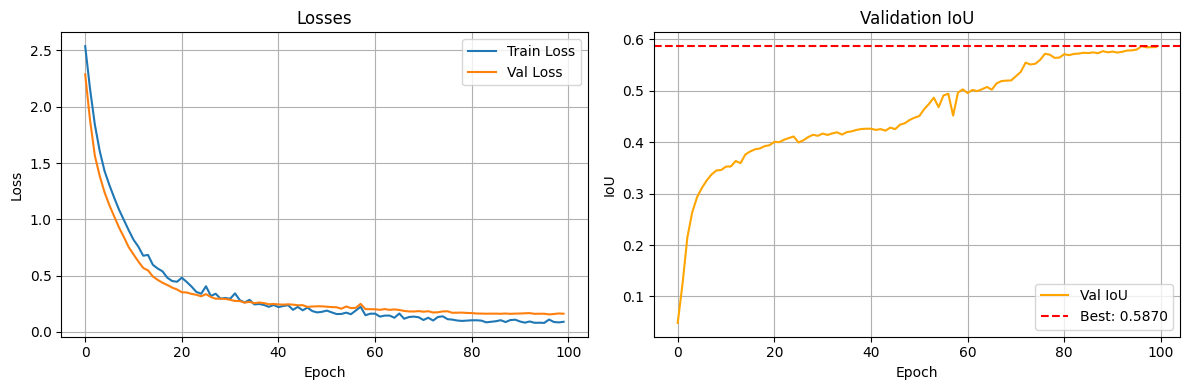


📊 Итоговый лучший IoU: 0.5870


In [ ]:
from tqdm import tqdm
import matplotlib.pyplot as plt


# Параметры для early stopping
PATIENCE = 15
best_iou = 0
patience_counter = 0
train_losses = []
val_losses = []

val_ious = []


# Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)

for epoch in tqdm(range(EPOCHS)):
    # Training
    model.train()
    train_loss = 0
    
    for img_batch, mask_batch in train_loader:
        img_batch = img_batch.to(DEVICE)
        mask_batch = mask_batch.to(DEVICE)
        
        optimizer.zero_grad()
        
        output = model(img_batch)
        loss = criterion(output, mask_batch)
        
        loss.backward()
        optimizer.step()    
        
        train_loss += loss.item()
            
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    val_iou = 0
    val_loss = 0
    
    intersection = torch.zeros(NUM_CLASSES).to(DEVICE)
    union = torch.zeros(NUM_CLASSES).to(DEVICE)
    
    with torch.no_grad():
        for img_batch, mask_batch in val_loader:
            img_batch = img_batch.to(DEVICE)
            mask_batch = mask_batch.to(DEVICE)
            
            output = model(img_batch)
            
            # Validation loss
            val_loss += criterion(output, mask_batch).item()
            
            # IoU calculation
            pred = torch.argmax(output, dim=1)
            
            for cls in range(NUM_CLASSES):
                pred_cls = (pred == cls)
                mask_cls = (mask_batch == cls)
                intersection[cls] += (pred_cls & mask_cls).sum()
                union[cls] += (pred_cls | mask_cls).sum()
                    
    iou = intersection / (union + 1e-7)
    avg_val_iou = iou.mean().item()
    
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_ious.append(avg_val_iou)
    
    scheduler.step(avg_val_iou)
    
    print(f"\nEpoch {epoch+1}:")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Val Loss: {avg_val_loss:.4f}")
    print(f"  Val IoU: {avg_val_iou:.4f}")
    print(f"  LR: {optimizer.param_groups[0]['lr']:.2e}")
    
    # Save best model
    if avg_val_iou > best_iou:
        best_iou = avg_val_iou
        patience_counter = 0
        
        path_model = CUR_DIR / "models"
        path_model.mkdir(exist_ok=True)
        
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_iou': best_iou,
            'palette': palette,
            'num_classes': NUM_CLASSES
        }, path_model / 'best_rgb_model.pth')
        
        print(f" Модель сохранена! Best IoU: {best_iou:.4f}")
    else:
        patience_counter += 1
        print(f" Patience: {patience_counter}/{PATIENCE}")
    
    # Early stopping
    if patience_counter >= PATIENCE:
        print(f"\n Early stopping на эпохе {epoch+1}")
        break

# Plot results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(val_ious, label='Val IoU', color='orange')
plt.axhline(y=best_iou, color='r', linestyle='--', label=f'Best: {best_iou:.4f}')
plt.title('Validation IoU')
plt.xlabel('Epoch')
plt.ylabel('IoU')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"\n Итоговый лучший IoU: {best_iou:.4f}")

In [53]:
from torch.utils.data import Dataset, DataLoader

class DepthSegmentation_Dataset(Dataset):
    def __init__(self, images, masks, depth_maps, palette, augmentation = True):
        self.images = images
        self.masks = masks
        self.depth_maps = depth_maps
        self.palette = palette
        self.augment = augmentation
        
        self.img_transform = T.Compose([
            T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            T.ToTensor(),
            T.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),
        ])
        
        self.mask_transform = T.Compose([
            T.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=T.InterpolationMode.NEAREST)
        ])

        self.depth_transform = T.Compose([
            T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            T.ToTensor()
        ])
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert("RGB")
        mask = Image.open(self.masks[idx]).convert("RGB")
        depth = Image.open(self.depth_maps[idx]).convert("L")
        
        # Преобразуем маску в классы
        class_mask_np = rgb_mask_to_class(mask, self.palette)
        
        # Преобразуем в PIL Image
        class_mask_pil = Image.fromarray(class_mask_np)
        
        # Применяем трансформации к изображению
        image = self.img_transform(image)
            
        # Для маски используем только изменение размера
        
        class_mask_pil = self.mask_transform(class_mask_pil)
            
        # Преобразуем маску в тензор вручную
        class_mask_tensor = torch.from_numpy(np.array(class_mask_pil)).long()
        
        depth = self.depth_transform(depth)
        img_dpth = torch.cat([image, depth], dim=0)
        
        return img_dpth, class_mask_tensor

In [54]:
all_depths = sorted(list(DEPTH_DIR.iterdir()), key=lambda x: int(str(x).split('_')[-1].split('.')[0]))

train_dataset = DepthSegmentation_Dataset(images[:train_size], masks[:train_size], all_depths[:train_size], palette, augmentation=True)
val_dataset = DepthSegmentation_Dataset(images[train_size:], masks[train_size:], all_depths[train_size:], palette, augmentation=False)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    num_workers=6,
    generator=g,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    num_workers=6,
    shuffle=False
)

model = smp.Unet(
    encoder_name='efficientnet-b3',
    encoder_weights="imagenet", 
    in_channels=4,
    classes=NUM_CLASSES,
    activation=None
).to(DEVICE)


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

  0%|          | 0/100 [00:00<?, ?it/s]


Epoch 1:
  Train Loss: 2.3034
  Val Loss: 2.0871
  Val IoU: 0.0896
  LR: 1.00e-04


  1%|          | 1/100 [00:13<22:16, 13.50s/it]

Модель сохранена. Best IoU: 0.0896

Epoch 2:
  Train Loss: 1.8874
  Val Loss: 1.7012
  Val IoU: 0.1384
  LR: 1.00e-04


  2%|▏         | 2/100 [00:26<21:57, 13.45s/it]

...


Epoch 89:
  Train Loss: 0.0963
  Val Loss: 0.1862
  Val IoU: 0.4869
  LR: 1.25e-05
Patience: 13/15


 90%|█████████ | 90/100 [19:58<02:11, 13.12s/it]


Epoch 90:
  Train Loss: 0.0932
  Val Loss: 0.1862
  Val IoU: 0.4869
  LR: 1.25e-05
Patience: 14/15


 90%|█████████ | 90/100 [20:12<02:14, 13.47s/it]


Epoch 91:
  Train Loss: 0.0933
  Val Loss: 0.1865
  Val IoU: 0.4863
  LR: 1.25e-05
Patience: 15/15
Early stopping на эпохе 91


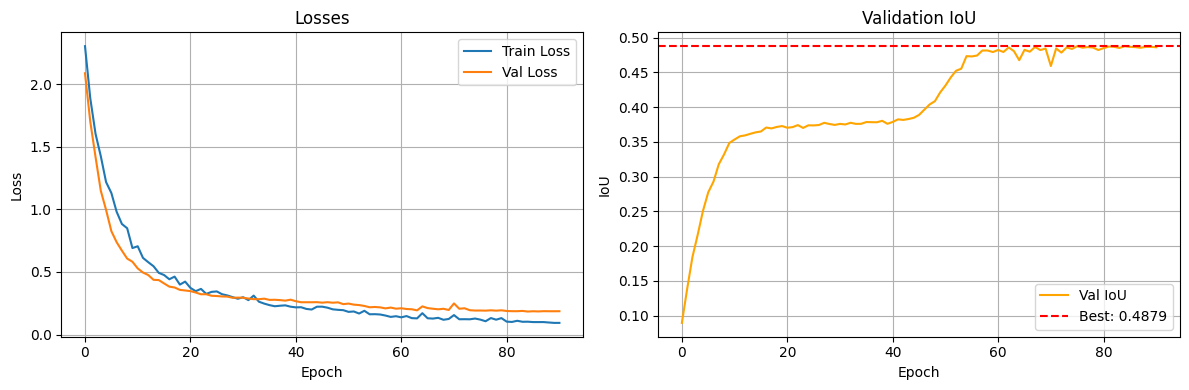


📊 Итоговый лучший IoU: 0.4879


In [ ]:
from tqdm import tqdm
import matplotlib.pyplot as plt

# Параметры для early stopping
PATIENCE = 15
best_iou = 0
patience_counter = 0
train_losses = []
val_ious = []
val_losses = []

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)

for epoch in tqdm(range(EPOCHS)):

    model.train()
    train_loss = 0
    
    for img_batch, mask_batch in train_loader:
        img_batch = img_batch.to(DEVICE)
        mask_batch = mask_batch.to(DEVICE)
        
        optimizer.zero_grad()
        
        output = model(img_batch)
        loss = criterion(output, mask_batch)
        
        loss.backward()
        optimizer.step()    
        
        train_loss += loss.item()
            
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    val_iou = 0
    val_loss = 0
    
    intersection = torch.zeros(NUM_CLASSES).to(DEVICE)
    union = torch.zeros(NUM_CLASSES).to(DEVICE)
    
    with torch.no_grad():
        for img_batch, mask_batch in val_loader:
            img_batch = img_batch.to(DEVICE)
            mask_batch = mask_batch.to(DEVICE)
            
            output = model(img_batch)
            
            # Validation loss
            val_loss += criterion(output, mask_batch).item()
            
            # IoU calculation
            pred = torch.argmax(output, dim=1)
            
            for cls in range(NUM_CLASSES):
                pred_cls = (pred == cls)
                mask_cls = (mask_batch == cls)
                intersection[cls] += (pred_cls & mask_cls).sum()
                union[cls] += (pred_cls | mask_cls).sum()
    
    iou = intersection / (union + 1e-7)
    avg_val_iou = iou.mean().item()
    
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_ious.append(avg_val_iou)
    
    scheduler.step(avg_val_iou)
    
    print(f"\nEpoch {epoch+1}:")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Val Loss: {avg_val_loss:.4f}")
    print(f"  Val IoU: {avg_val_iou:.4f}")
    print(f"  LR: {optimizer.param_groups[0]['lr']:.2e}")
    
    # Save best model
    if avg_val_iou > best_iou:
        best_iou = avg_val_iou
        patience_counter = 0
        
        path_model = CUR_DIR / "models"
        path_model.mkdir(exist_ok=True)
        
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_iou': best_iou,
            'palette': palette,
            'num_classes': NUM_CLASSES
        }, path_model / 'best_depth_model.pth')
        
        print(f"Модель сохранена. Best IoU: {best_iou:.4f}")
    else:
        patience_counter += 1
        print(f"Patience: {patience_counter}/{PATIENCE}")
    
    # Early stopping
    if patience_counter >= PATIENCE:
        print(f"Early stopping на эпохе {epoch+1}")
        break


plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(val_ious, label='Val IoU', color='orange')
plt.axhline(y=best_iou, color='r', linestyle='--', label=f'Best: {best_iou:.4f}')
plt.title('Validation IoU')
plt.xlabel('Epoch')
plt.ylabel('IoU')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"\n Итоговый лучший IoU: {best_iou:.4f}")